In [550]:
import numpy as np
import matplotlib.pyplot as plt
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import shift
def processSignals(ref, echo, burst_len, num_steps):
    signal_ratio = echo*np.conjugate(ref);
    #signal_ratio = echo/ref
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    return freq_response, s

def B_scan(dir, prefix, burst_len, num_steps):
    supposed_size = burst_len*num_steps
    s_list = []
    for i in range(14):
        #print(i)
        fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
        fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
        
        ref_samples = np.fromfile(fileName_ref, np.complex64)
        N = supposed_size - ref_samples.size
        #print(ref_samples.size,N)
        if N>=0:
            ref_samples = np.pad(ref_samples,(0,N),'constant')
        else:
            ref_samples = ref_samples[0:supposed_size]
        
        rx_samples = np.fromfile(fileName_rx, np.complex64)  
        N = supposed_size - rx_samples.size
        #print(rx_samples.size,N)
        if N>=0:
            rx_samples = np.pad(rx_samples,(0,N),'constant')
        else:
            rx_samples = rx_samples[0:supposed_size]
        
        f,s = processSignals(ref_samples, rx_samples, burst_len, num_steps)
        s_list.append(s)
    return np.stack(s_list, axis=0)   

def normaliseSignals(input_sammples,burst_len,num_steps):
    samples = np.reshape(input_sammples,[num_steps,-1])
    print(samples.shape)
    samples_real = np.real(samples)
    samples_imag = np.imag(samples)
    max_val = np.max(samples_real,axis=1)
    min_val = np.min(samples_real,axis=1)
    samples_real_normalised = 2*(np.transpose(samples_real)-min_val)/(max_val-min_val)-1
    samples_real_normalised = np.transpose(samples_real_normalised).ravel()
    max_val = np.max(samples_imag,axis=1)
    min_val = np.min(samples_imag,axis=1)
    samples_imag_normalised = 2*(np.transpose(samples_imag)-min_val)/(max_val-min_val)-1
    samples_imag_normalised = np.transpose(samples_imag_normalised).ravel()
    return samples_real_normalised+1j*samples_imag_normalised

from pylab import *
def fix_iq_imbalance(x):
    # remove DC and save input power
    z = x - mean(x)
    p_in = var(z)

    # scale Q to have unit amplitude (remember we're assuming a single input tone)
    Q_amp = sqrt(2*mean(x.imag**2))
    z /= Q_amp

    I, Q = z.real, z.imag

    alpha_est = sqrt(2*mean(I**2))
    sin_phi_est = (2/alpha_est)*mean(I*Q)
    cos_phi_est = sqrt(1 - sin_phi_est**2)

    I_new_p = (1/alpha_est)*I
    Q_new_p = (-sin_phi_est/alpha_est)*I + Q

    y = (I_new_p + 1j*Q_new_p)/cos_phi_est

    #print ('phase error:', arccos(cos_phi_est)*360/2/pi, 'degrees')
    #print ('amplitude error:', 20*log10(alpha_est), 'dB')

    return y*sqrt(p_in/var(y))

def plot_chirp_frequency(chirp, fs):
  """
  Plots the instantaneous frequency of a chirp signal over time.

  Args:
    chirp: Complex chirp signal (numpy array).
    fs: Sampling rate (Hz).
  """

  # Calculate the instantaneous frequency using the derivative of the phase.
  phase = np.unwrap(np.angle(chirp))
  inst_freq = fs * np.diff(phase) / (2 * np.pi)

  # Create the time vector for the instantaneous frequency.
  t = np.arange(len(inst_freq)) / fs

  # Plot the instantaneous frequency.
  plt.plot(t, inst_freq)
  plt.xlabel("Time (s)")
  plt.ylabel("Instantaneous Frequency (Hz)")
  plt.title("Chirp Frequency Over Time")
  plt.grid(True)
  plt.show()

524288 0
524288 0
(64, 8192)
(64, 8192)


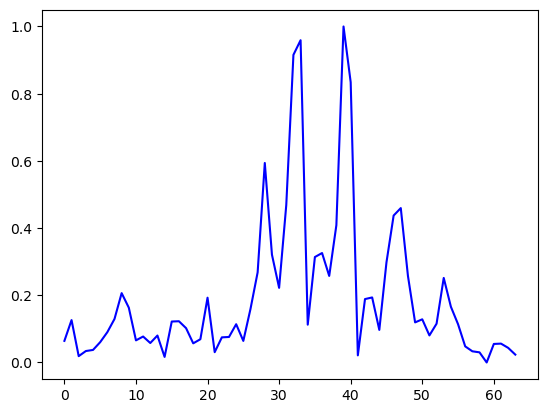

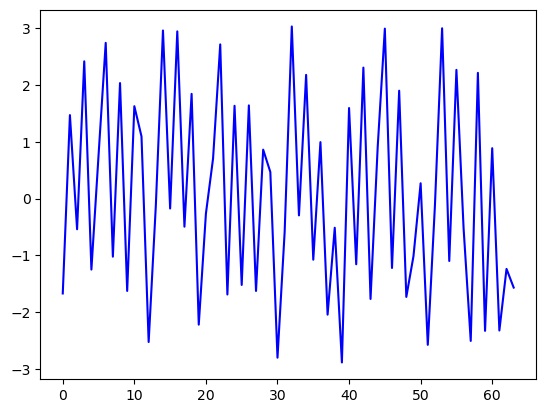

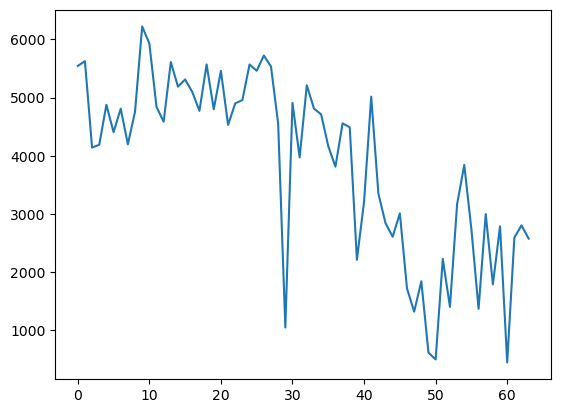

In [549]:
burst_len = 8192
num_steps = 64
supposed_size = burst_len*num_steps
dir = '../gui/'
prefix = 'chirp_5m'
i=2
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
ref_samples = np.fromfile(fileName_ref, np.complex64)
N = supposed_size - ref_samples.size
print(ref_samples.size,N)
if N>=0:
    ref_samples = np.pad(ref_samples,(0,N),'constant')
else:
    ref_samples = ref_samples[0:supposed_size]

rx_samples = np.fromfile(fileName_rx, np.complex64)  
N = supposed_size - rx_samples.size
print(rx_samples.size,N)
if N>0:
    rx_samples = np.pad(rx_samples,(0,N),'constant')
else:
    rx_samples = rx_samples[0:supposed_size]

ref_complex_normalised = normaliseSignals(ref_samples,burst_len,num_steps)
rx_complex_normalised = normaliseSignals(rx_samples,burst_len,num_steps)

rx_samples_reshaped = rx_samples.reshape([num_steps,-1])
ref_samples_reshaped = ref_samples.reshape([num_steps,-1])
# #ref_samples_reshaped = ref.reshape([num_steps,-1])
# rx_samples_reshaped = rx_samples_reshaped[:,256:256+512]
# ref_samples_reshaped = ref_samples_reshaped[:,256:256+512]
# rx_samples = rx_samples_reshaped.flatten()
# ref_samples = ref_samples_reshaped.flatten()

signal_matched_filtered = []
output_f = []
#matched_filters = np.conj(np.flip(ref,axis=1))
#matched_filters = np.conj(ref_samples_reshaped,axis=1)
#print(matched_filters.shape[0])
for i in range(num_steps):
    #output = np.fft.fftshift(np.fft.fft(rx_samples_reshaped[i]))*np.fft.fftshift(np.conj(np.fft.fft(ref_samples_reshaped[i])))
    #output = np.fft.fft(rx_samples_reshaped[i])*np.conj(np.fft.fft(ref_samples_reshaped[i]))
    #matched_filter = np.conj(np.flip(fix_iq_imbalance(ref_samples_reshaped[i])))
    #output = np.convolve(fix_iq_imbalance(rx_samples_reshaped[i]),matched_filter)
    #output = signal.correlate(fix_iq_imbalance(rx_samples_reshaped[i]), fix_iq_imbalance(ref_samples_reshaped[i]), mode='same')
    output = signal.correlate(rx_samples_reshaped[i], ref_samples_reshaped[i], mode='same')
    # output[0:269] = 0
    # output[390:] = 0
    signal_matched_filtered.append(output)
    # #f = np.fft.fft(output)
    f = output
    # f[0:260] = 0
    # f[390:] = 0
    index = np.argmax(np.abs(f))
    output_f.append(f[index])
    # output_f.append(output)
signal_matched_filtered = np.array(signal_matched_filtered)
output_f = np.array(output_f)
output_f.shape

s_mf = np.hamming(num_steps)*output_f
#s_mf = output_f
s_mf = np.fft.ifft(s_mf)
range_profile_mf = np.abs(s_mf)
min_v = np.min(range_profile_mf)
max_v = np.max(range_profile_mf)
range_profile_mf = (range_profile_mf - min_v)/(max_v-min_v)
# plt.plot(range_profile,color='red')
# plt.figure()
# plt.plot(np.angle(output_f))
plt.figure()
#plt.plot(range_profile,color='red')
plt.plot(range_profile_mf,color='blue')
plt.figure()
#plt.plot(np.angle(f),color = 'red')
plt.plot(np.angle(output_f),color='blue')
plt.figure()
plt.plot(np.abs(output_f))

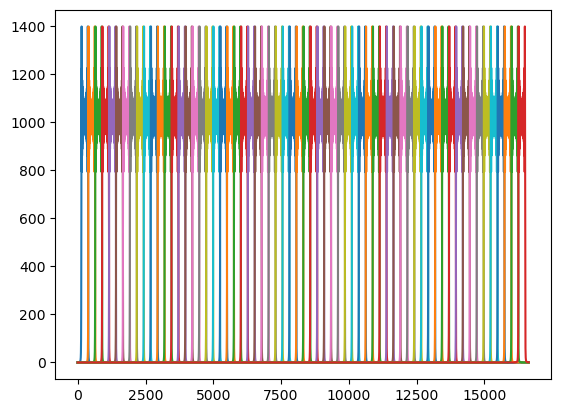

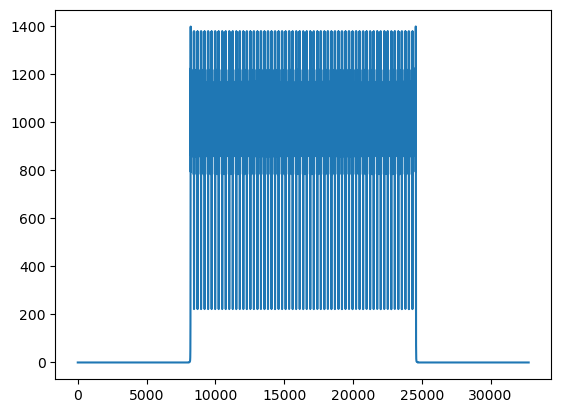

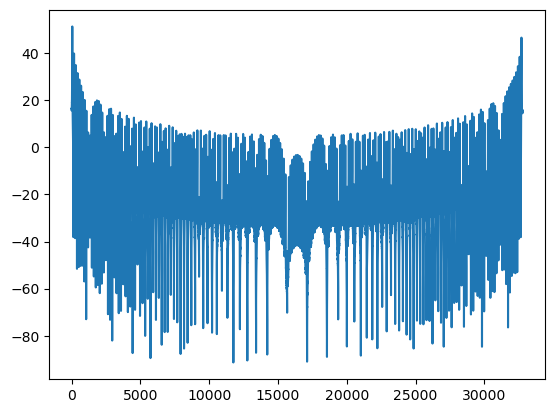

In [547]:
def complex_chirp(n_samples, f0, f1, fs, phi0=0):
  """
  Generate a complex chirp signal.

  Args:
    n_samples: Number of samples.
    f0: Start frequency (Hz).
    f1: End frequency (Hz).
    fs: Sampling rate (Hz).
    phi0: Initial phase (radians).

  Returns:
    Complex chirp signal (numpy array).
  """

  # Create the time vector.
  t = np.arange(n_samples) / fs

  # Calculate the instantaneous frequency at each time point.
  f_inst = np.linspace(f0, f1, n_samples)

  # Calculate the phase at each time point.
  phase = 2 * np.pi * np.cumsum(f_inst) * (t[1] - t[0]) + phi0

  # Generate the complex chirp signal.
  chirp = np.exp(1j * phase)

  return chirp

burst_len=512
N = 64
refChirp = complex_chirp(burst_len,-2.5e6,2.5e6,10e6,0)
chirp_mf_list = []
for i in range(N):
    aChirp = complex_chirp(burst_len,-2.5e6,2.5e6,10e6,i*4)
    chirp_mf = np.fft.fftshift(np.fft.fft(aChirp)*np.conj(np.fft.fft(refChirp)))
    chirp_mf_list.append(chirp_mf)
chirp_mf_list_np = np.array(chirp_mf_list)

# chirp_mf = np.fft.fftshift(np.fft.fft(aChirp)*np.conj(np.fft.fft(refChirp)))
# #plot_chirp_frequency(aChirp,10e6)
# plt.plot(10*np.log10(np.abs(chirp_mf)**2))

plt.figure()

final_result = np.pad(chirp_mf_list_np[0],[0,(N-1)*int(burst_len/2)],'constant',constant_values=(0.01))
#print(final_result.shape)
plt.plot(np.abs(final_result))
for i in range(1,N):
    chirp_pad = np.pad(chirp_mf_list_np[i],[0,(N-1)*int(burst_len/2)],'constant',constant_values=(0.01))
    #print(chirp_pad.shape)
    chirp_pad_shift = shift(chirp_pad,int(burst_len/2)*i,cval=0)
    plt.plot(np.abs(chirp_pad_shift))
    final_result = final_result+chirp_pad_shift

final_result = np.pad(final_result,[int(burst_len/2)*int(N/2-1)+int(burst_len/4),int(burst_len/2)*int(N/2-1)+int(burst_len/4)],'constant')
plt.figure()
plt.plot(np.abs(final_result))

plt.figure()
range_profile = np.fft.ifft(final_result)
plt.plot(10*np.log10(np.abs(range_profile)**2))

# plt.figure()
# auto_corr = signal.correlate(final_result, final_result)
# plt.plot(10*np.log10(np.abs(auto_corr)**2))

In [541]:
final_result.shape[0]-512*64

0

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def rect_function(x, width=1):
  """
  This function implements a rectangular function (also known as a gate function or unit pulse).

  Args:
    x: The input value or array.
    width: The width of the rectangle.

  Returns:
    The value of the rectangular function at x.
  """
  if isinstance(x, np.ndarray):
    result = np.zeros_like(x, dtype=float)
    result[np.abs(x) <= width / 2] = 1
    return result
  else:
    if abs(x) <= width / 2:
      return 1.0
    else:
      return 0.0

# Example usage
x = np.linspace(-512, 512, 1024)
y = rect_function(x, width=20)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("rect(x)")
plt.title("Rectangular Function")
plt.grid(True)
plt.show()

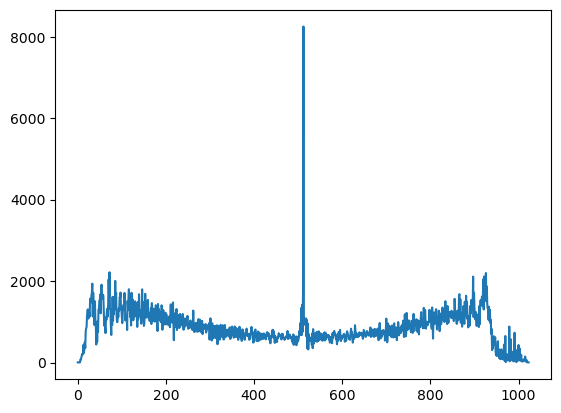

In [351]:
plt.plot(np.abs(signal_matched_filtered[20]))

In [352]:
tmp = signal_matched_filtered[i]

(261120,)


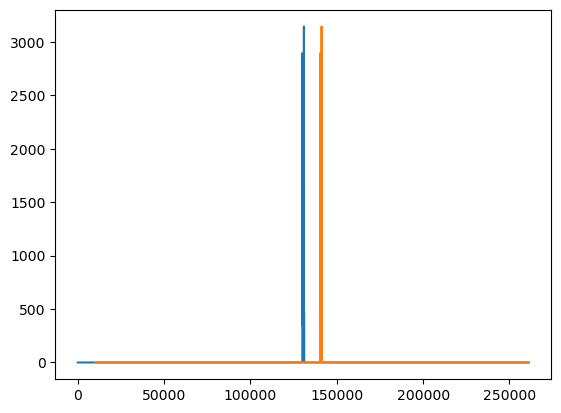

In [353]:
i=64
tmp_pad = np.pad(tmp,(1024*127,1024*127),'constant')
plt.plot(np.abs(tmp_pad))
print(tmp_pad.shape)
tmp_pad_shifted = shift(tmp_pad,1024*10,cval=np.NaN)
plt.plot(np.abs(tmp_pad_shifted))

In [354]:
tmp_pad_shifted_1 = shift(tmp_pad,1024*10,cval=np.NaN)
tmp_pad_shifted_2 = shift(tmp_pad,1024*20,cval=np.NaN)

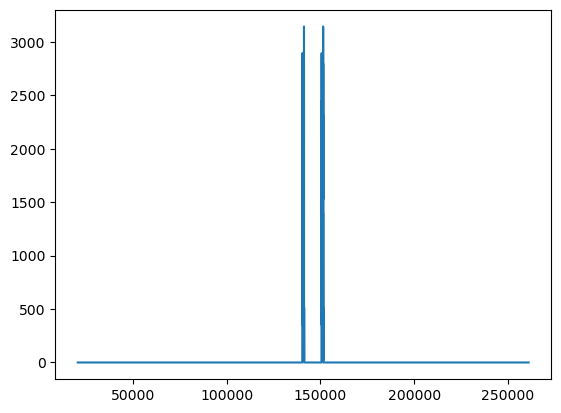

In [355]:
plt.plot(np.abs(tmp_pad_shifted_1 + tmp_pad_shifted_2))

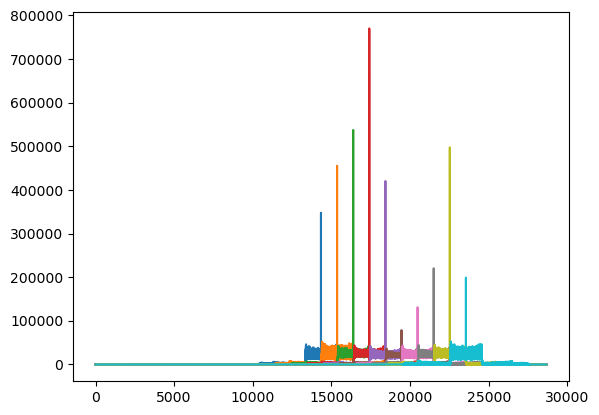

In [413]:
final_result = signal_matched_filtered[0]
N = 10
padding = N*1024;
final_result = np.pad(final_result,[padding,padding],'constant')
# final_result[0:260] = 0
# final_result[390:] = 0
plt.plot(np.abs(final_result))
for i in range(1,N):
    tmp = signal_matched_filtered[i]
    # tmp[0:260] = 0
    # tmp[390:] = 0
    tmp = np.pad(tmp,[padding,padding],'constant')
    tmp_pad_shifted = shift(tmp,1024*i,cval=0)
    plt.plot(np.abs(tmp_pad_shifted))
    final_result = final_result+tmp_pad_shifted

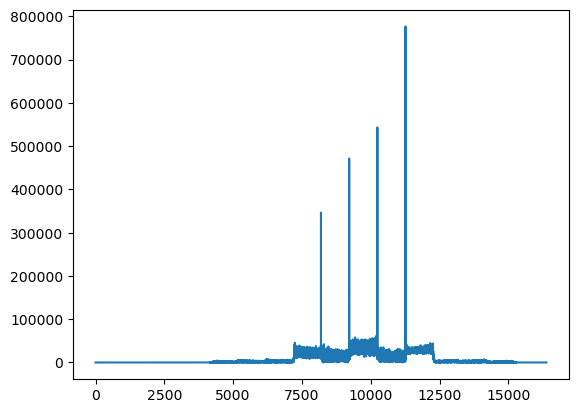

In [397]:
plt.plot(np.abs(final_result))

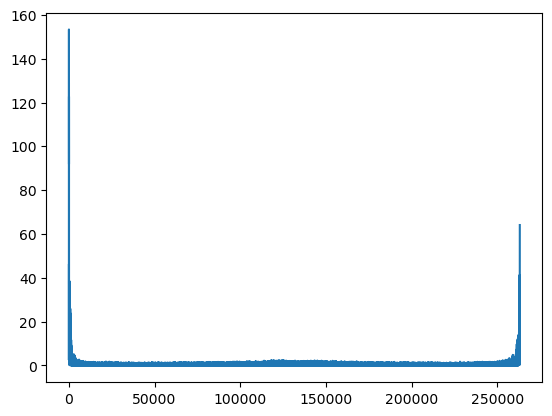

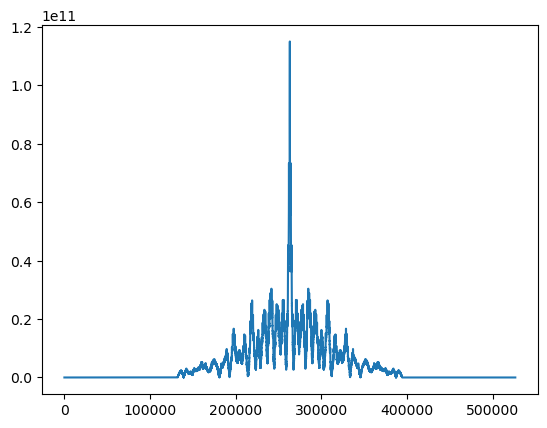

In [375]:
range_profile = np.fft.ifft(final_result)
plt.plot(np.abs(range_profile))

plt.figure()
autocorr = signal.correlate(final_result,final_result)
plt.plot(np.abs(autocorr))

In [312]:
autocorr

array([ 0.00000000e+00-9.35278713e-07j,  8.18368874e-07+5.84549196e-07j,
        6.43004115e-07-1.28600823e-06j, ...,
       -2.19205948e-07-7.01459035e-07j,  1.16909839e-07-9.35278713e-07j,
       -2.19205948e-07+8.76823793e-07j])

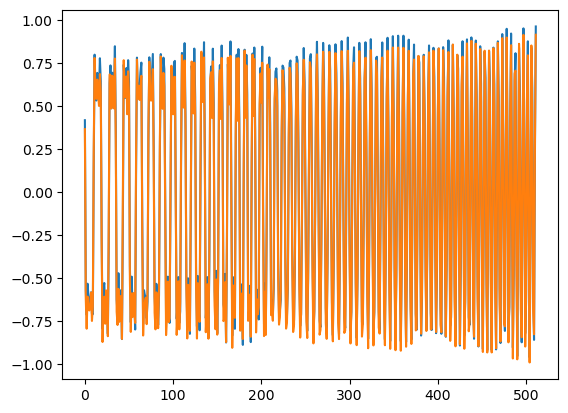

In [268]:
plt.plot(np.real(rx_samples_reshaped[0]))
plt.plot(np.real(ref_samples_reshaped[0]))

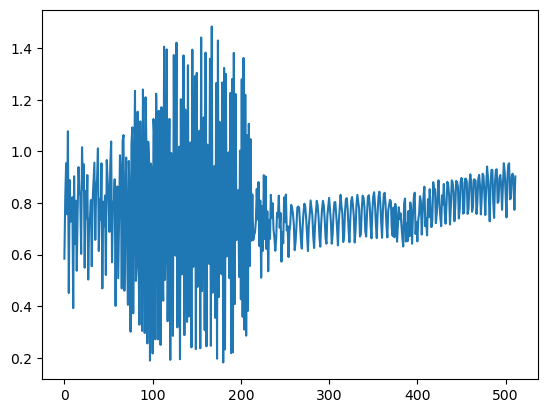

In [269]:
plt.plot(np.real(rx_samples_reshaped[0]*np.conj(ref_samples_reshaped[0])))